In [73]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import os

# Import Library

In [74]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return canvas

def sobel(img):
    sobelX = np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ], dtype=np.float32)
    sobelY = np.array([
        [ 1,  2,  1],
        [ 0,  0,  0],
        [-1, -2, -1]
    ], dtype=np.float32)
    gx = convolution(img, sobelX)
    gy = convolution(img, sobelY)
    result = np.abs(gx) + np.abs(gy)
    result = result * 255.0 / np.max(result)
    return np.clip(result, 0, 255).astype(np.uint8)

# Fungsi Preprocessing Sobel

In [75]:
def dilasi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width))
    for i in range(center, height - center):
        for j in range(center, width - center):
            if image[i, j] > 0:  
                for k in range(k_height):
                    for l in range(k_width):
                        if kernel[k, l] == 1:
                            hasil[i+k-center, j+l-center] = 255
            else:
                if hasil[i, j] != 255:
                    hasil[i, j] = 0
    return hasil

def erosi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width), dtype=np.uint8)
    for i in range(center, height - center):
        for j in range(center, width - center):
            cocok = True
            for k in range(k_height):
                for l in range(k_width):
                    if kernel[k, l] == 1 and image[i+k-center, j+l-center] == 0:
                        cocok = False
                        break
                if not cocok:
                    break
            if cocok:
                hasil[i, j] = 255
    return hasil

def closing(image, kernel):
    """Closing = Dilasi → Erosi"""
    return erosi(dilasi(image, kernel), kernel)

# Fungsi Preprocessing Closing

In [76]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    matrix = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return matrix

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]
def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]
def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]
def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]
def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]
def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]
def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [ ]:
def thresholding(img, batas):
    baris, kolom = img.shape
    canvas = np.zeros_like(img, dtype=np.uint8)

    for i in range(baris):
        for j in range(kolom):
            if img[i, j] > batas:
                canvas[i, j] = 255
            else:
                canvas[i, j] = 0

    return canvas

# Fungsi GLCM

In [78]:
dataset_path = "Dataset"
labels = ["Matang", "Rusak", "Tua"]

kernel_closing = np.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0]
], dtype=np.uint8)

data = []
contoh_gambar = {}

for label in labels:
    folder = os.path.join(dataset_path, label)
    simpan_contoh = True

    for img_name in sorted(os.listdir(folder)):
        img_path = os.path.join(folder, img_name)
        img = cv.imread(img_path)
        if img is None:
            continue

        # 1. Grayscale
        gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

        # 2. Resize
        resized = cv.resize(gray, (128, 128))

        # 3. Sobel
        sobel_result = sobel(resized)

        # 4. Threshold
        sobel_biner = thresholding(sobel_result, 30)

        # 5. Closing
        closed = closing(sobel_biner, kernel_closing)
        closed = np.uint8(closed)

        if simpan_contoh:
            contoh_gambar[label] = {
                'asli'   : img,
                'gray'   : resized,
                'sobel'  : sobel_result,
                'closing': closed
            }
            simpan_contoh = False

        baris = {'filename': img_name, 'label': label}
        for derajat in [0, 45, 90, 135]:
            matriks = glcm(closed, derajat)
            baris[f'Correlation{derajat}']   = correlation(matriks)
            baris[f'Contrast{derajat}']      = contrast(matriks)
            baris[f'Dissimilarity{derajat}'] = dissimilarity(matriks)
            baris[f'Homogeneity{derajat}']   = homogenity(matriks)
            baris[f'ASM{derajat}']           = ASM(matriks)
            baris[f'Energy{derajat}']        = energy(matriks)
            baris[f'Entropy{derajat}']       = entropyGlcm(matriks)
        data.append(baris)

print(f"Total gambar diproses: {len(data)}")
print(f"Sobel max: {sobel_result.max()}, min: {sobel_result.min()}")
print(f"Closed max: {closed.max()}, min: {closed.min()}")

Total gambar diproses: 294
Sobel max: 255, min: 0
Closed max: 255, min: 0


Distribusi Dataset:
  Matang: 100 gambar
  Rusak: 96 gambar
  Tua: 98 gambar


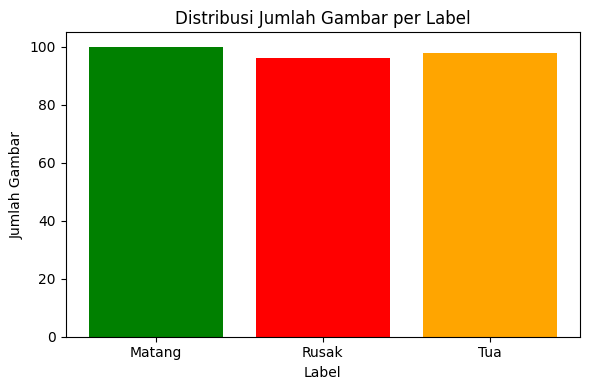

In [79]:
jumlah_per_label = {label: 0 for label in labels}
for d in data:
    jumlah_per_label[d['label']] += 1

print("Distribusi Dataset:")
for label, jumlah in jumlah_per_label.items():
    print(f"  {label}: {jumlah} gambar")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(jumlah_per_label.keys(),
       jumlah_per_label.values(),
       color=['green', 'red', 'orange'])
ax.set_title('Distribusi Jumlah Gambar per Label')
ax.set_xlabel('Label')
ax.set_ylabel('Jumlah Gambar')
plt.tight_layout()
plt.show()

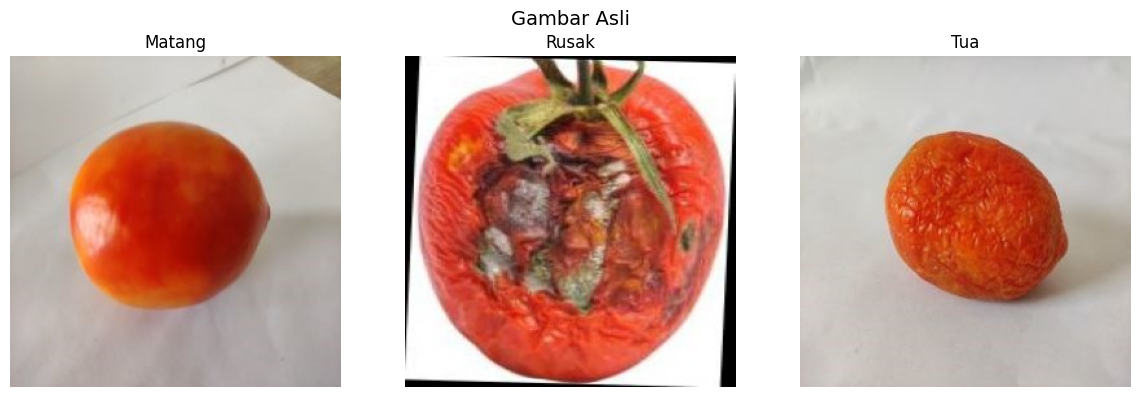

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, label in enumerate(labels):
    axes[i].imshow(cv.cvtColor(contoh_gambar[label]['asli'], cv.COLOR_BGR2RGB))
    axes[i].set_title(label)
    axes[i].axis('off')
plt.suptitle('Gambar Asli', fontsize=14)
plt.tight_layout()
plt.show()

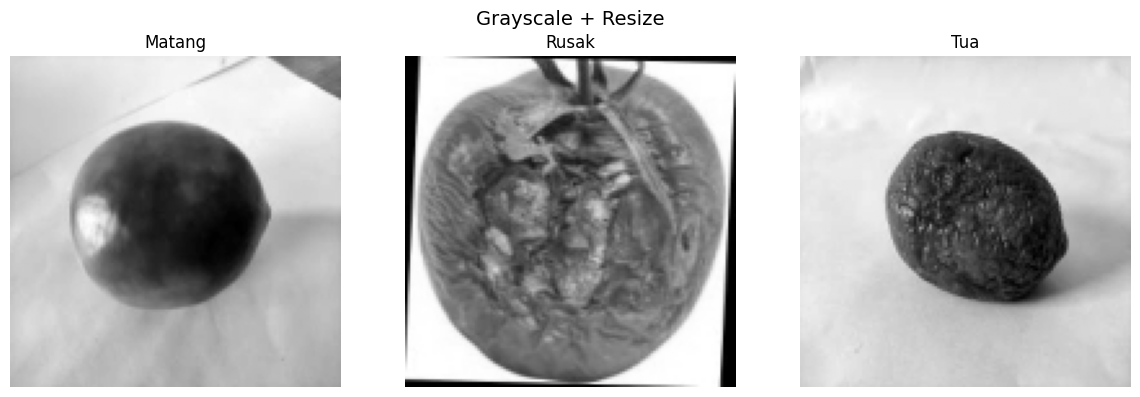

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, label in enumerate(labels):
    axes[i].imshow(contoh_gambar[label]['gray'], cmap='gray')
    axes[i].set_title(label)
    axes[i].axis('off')
plt.suptitle('Grayscale + Resize', fontsize=14)
plt.tight_layout()
plt.show()

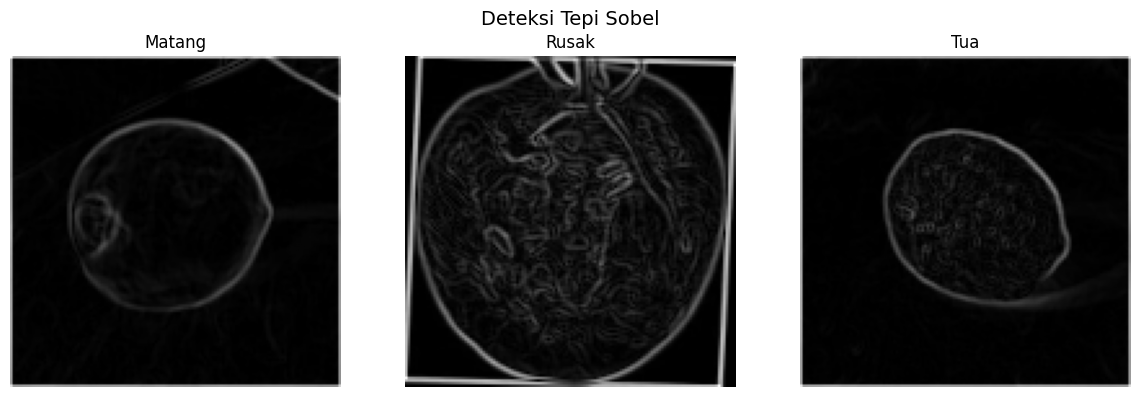

In [82]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, label in enumerate(labels):
    axes[i].imshow(contoh_gambar[label]['sobel'], cmap='gray')
    axes[i].set_title(label)
    axes[i].axis('off')
plt.suptitle('Deteksi Tepi Sobel', fontsize=14)
plt.tight_layout()
plt.show()

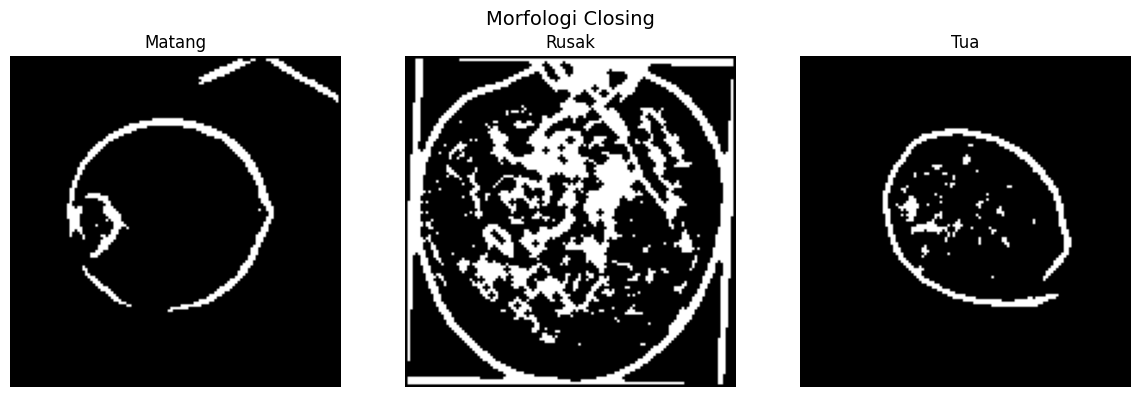

In [83]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, label in enumerate(labels):
    axes[i].imshow(contoh_gambar[label]['closing'], cmap='gray')
    axes[i].set_title(label)
    axes[i].axis('off')
plt.suptitle('Morfologi Closing', fontsize=14)
plt.tight_layout()
plt.show()

Total gambar: 294
           filename   label  Correlation0    Contrast0  Dissimilarity0  \
0    Matang (1).jpg  Matang      0.742226  1576.024237        6.180487   
1   Matang (10).jpg  Matang      0.746125   856.013164        3.356914   
2  Matang (100).jpg  Matang      0.712124  2280.035064        8.941314   
3   Matang (11).jpg  Matang      0.720567   712.010950        2.792200   
4   Matang (12).jpg  Matang      0.657401   936.014395        3.670645   

   Homogeneity0      ASM0   Energy0  Entropy0  Correlation45  ...     ASM90  \
0      0.975763  0.882325  0.939322  0.289363       0.632161  ...  0.878943   
1      0.986836  0.935155  0.967034  0.177188       0.729458  ...  0.937437   
2      0.964937  0.844363  0.918892  0.365916       0.624040  ...  0.848617   
3      0.989050  0.949984  0.974671  0.143607       0.638877  ...  0.949623   
4      0.985606  0.943796  0.971492  0.159923       0.630984  ...  0.945832   

   Energy90  Entropy90  Correlation135  Contrast135  Dissimila

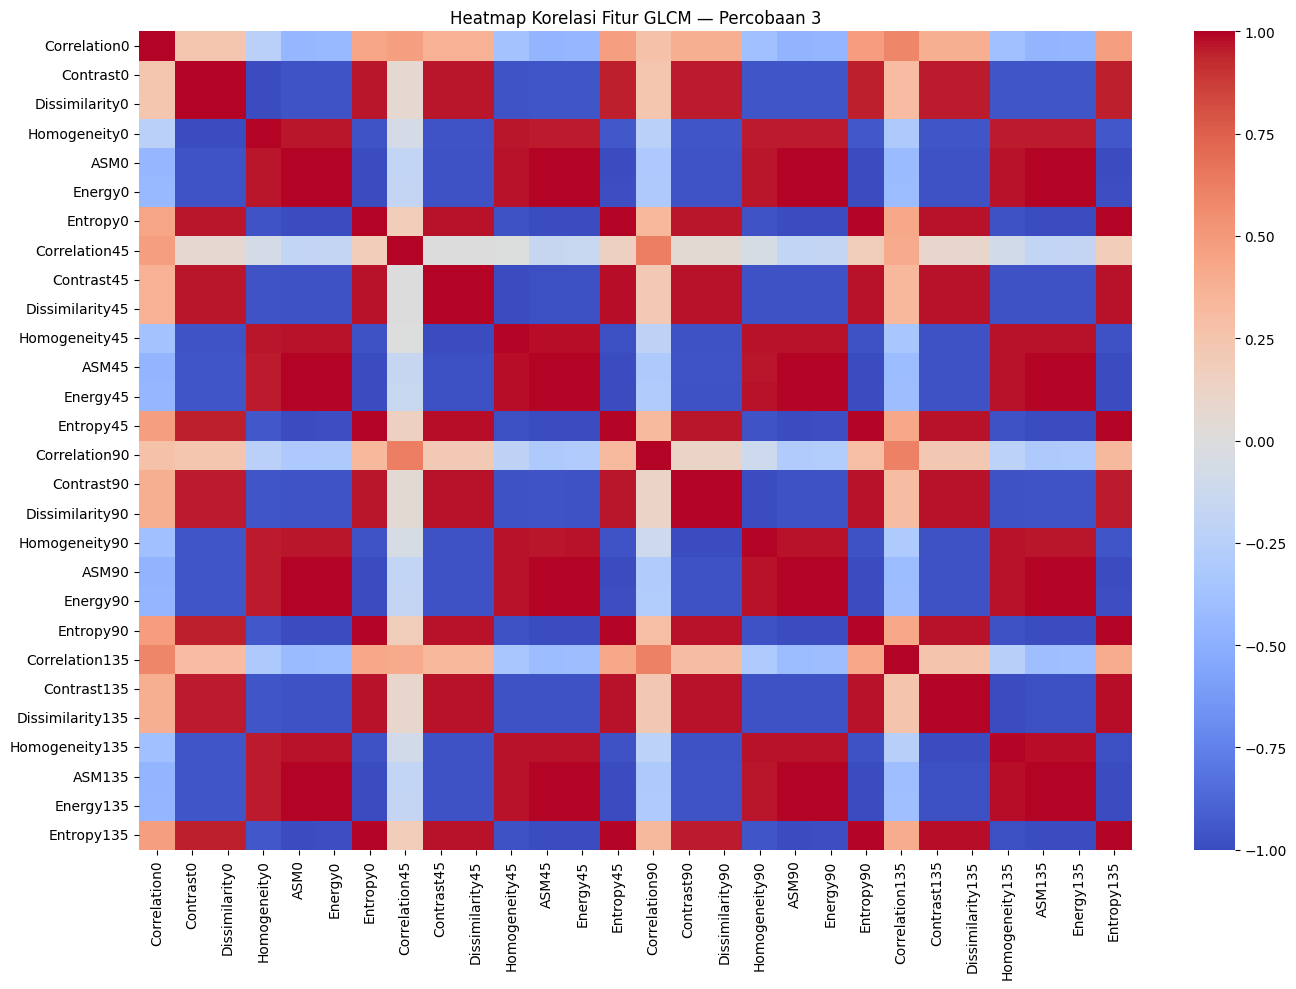

In [84]:
df = pd.DataFrame(data)
df.to_csv("hasil_p3.csv", index=False)
print(f"Total gambar: {len(df)}")
print(df.head())

# Feature Selection — hapus fitur korelasi tinggi > 0.95
fitur = df.drop(columns=['filename', 'label'])
corr_matrix = fitur.corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
drop_cols = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f"\nFitur dihapus (korelasi tinggi): {drop_cols}")
fitur_selected = fitur.drop(columns=drop_cols)
print(f"Fitur tersisa: {fitur_selected.shape[1]} kolom")

# Heatmap Korelasi
plt.figure(figsize=(14, 10))
sns.heatmap(fitur.corr(), cmap='coolwarm', annot=False)
plt.title('Heatmap Korelasi Fitur GLCM — Percobaan 3')
plt.tight_layout()
plt.show()

In [85]:
X = fitur_selected
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalisasi fitur (standardisasi)
X_mean  = X_train.mean()
X_std   = X_train.std()
X_train = (X_train - X_mean) / X_std
X_test  = (X_test  - X_mean) / X_std

print(f"Data latih : {X_train.shape}")
print(f"Data uji   : {X_test.shape}")

Data latih : (235, 5)
Data uji   : (59, 5)


In [86]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# SVM
svm = SVC(random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

# KNN
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

# Tabel Akurasi
hasil = pd.DataFrame({
    'Model'   : ['Random Forest', 'SVM', 'KNN'],
    'Akurasi' : [
        f"{accuracy_score(y_test, y_pred_rf)  * 100:.2f}%",
        f"{accuracy_score(y_test, y_pred_svm) * 100:.2f}%",
        f"{accuracy_score(y_test, y_pred_knn) * 100:.2f}%"
    ]
})
print("===== HASIL PERCOBAAN 3 =====")
print(hasil.to_string(index=False))

===== HASIL PERCOBAAN 3 =====
        Model Akurasi
Random Forest  57.63%
          SVM  66.10%
          KNN  55.93%


In [87]:
print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))

print("=== SVM ===")
print(classification_report(y_test, y_pred_svm))

print("=== KNN ===")
print(classification_report(y_test, y_pred_knn))

=== Random Forest ===
              precision    recall  f1-score   support

      Matang       0.68      0.77      0.72        22
       Rusak       0.50      0.59      0.54        17
         Tua       0.50      0.35      0.41        20

    accuracy                           0.58        59
   macro avg       0.56      0.57      0.56        59
weighted avg       0.57      0.58      0.57        59

=== SVM ===
              precision    recall  f1-score   support

      Matang       0.71      0.91      0.80        22
       Rusak       0.71      0.59      0.65        17
         Tua       0.53      0.45      0.49        20

    accuracy                           0.66        59
   macro avg       0.65      0.65      0.64        59
weighted avg       0.65      0.66      0.65        59

=== KNN ===
              precision    recall  f1-score   support

      Matang       0.61      0.64      0.62        22
       Rusak       0.55      0.71      0.62        17
         Tua       0.50      

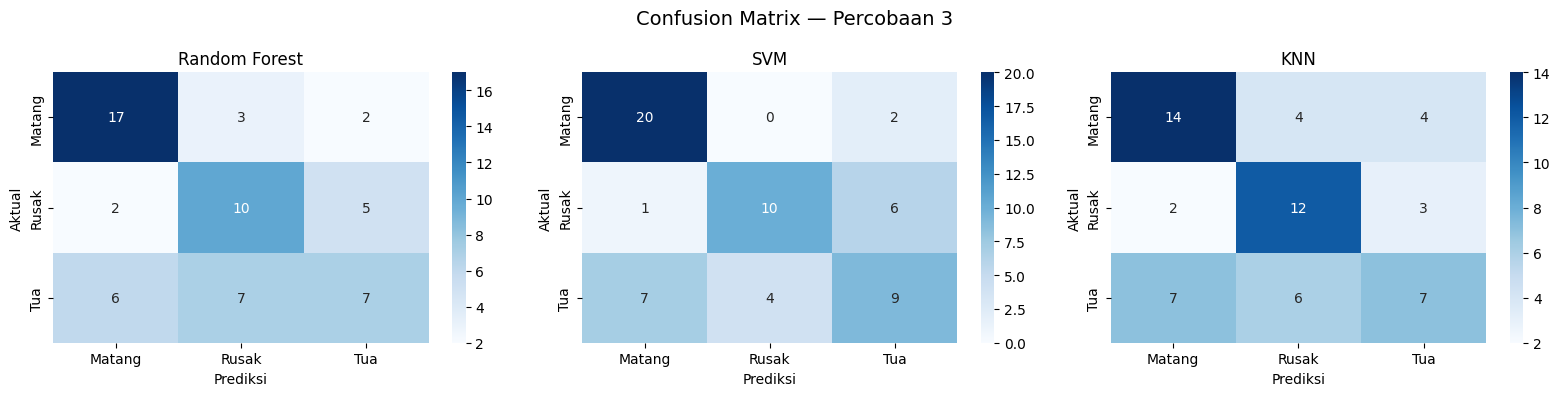

In [88]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
model_names = ['Random Forest', 'SVM', 'KNN']
preds       = [y_pred_rf, y_pred_svm, y_pred_knn]

for i, (name, pred) in enumerate(zip(model_names, preds)):
    cm = confusion_matrix(y_test, pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                ax=axes[i])
    axes[i].set_title(f'{name}')
    axes[i].set_xlabel('Prediksi')
    axes[i].set_ylabel('Aktual')

plt.suptitle('Confusion Matrix — Percobaan 3', fontsize=14)
plt.tight_layout()
plt.show()